In [24]:
import numpy as np
from joblib import Parallel, delayed
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge

from utils import TabularMissingness
from utils import load_iris
from utils import plot_performance_average, plot_experiment_results, plot_imputation_and_alignment
from utils import run_gmm_pipeline

In [25]:
missingness = TabularMissingness()

mean_imputer = SimpleImputer(strategy="mean")
knn_imputer = KNNImputer(n_neighbors=5)
iterative_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=25,
    tol=1e-1,
)

missingness_percentages = np.arange(0, 92.5, 2.5) / 100
n_runs = 50

# Missing at Random

## Loading Data

In [26]:
X, y, classes = load_iris(return_numpy=True, encode_labels=True)
n_classes = len(classes)

missing = missingness.apply_stratified(
    X, y,
    method="mar",
    frac=0.90,
    dep_col=0,
    miss_col=1,
)

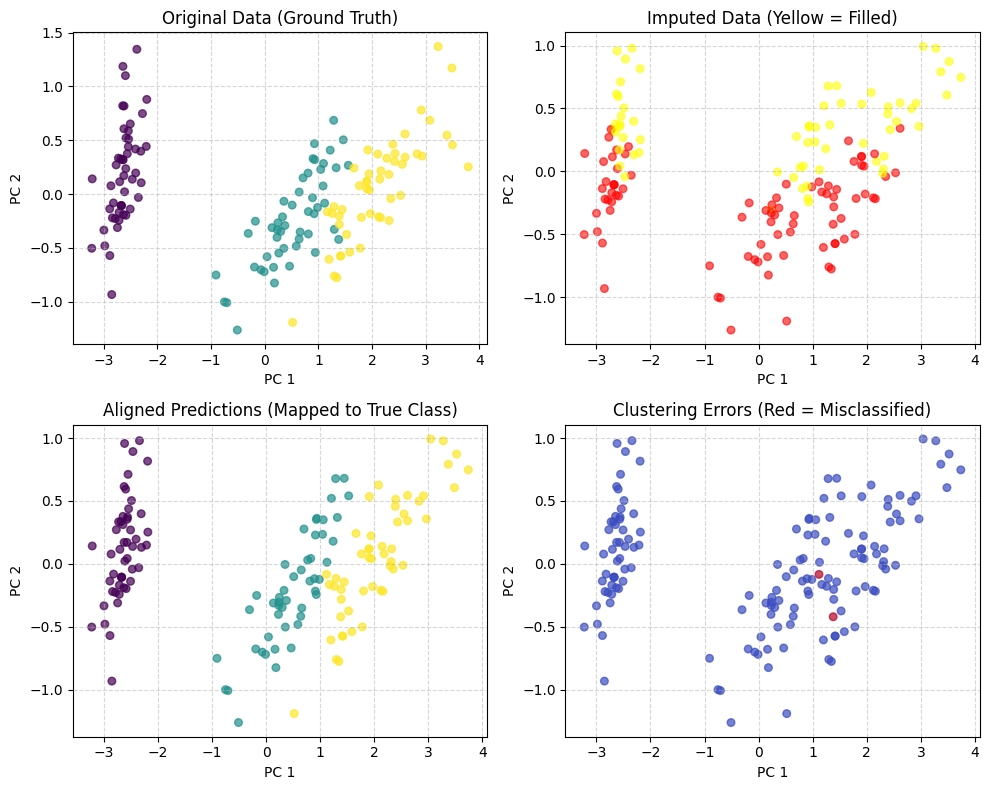

In [27]:
plot_imputation_and_alignment(X, y, n_classes, missing)

## Mean imputation

In [28]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_gmm_pipeline)(missingness_percentages, X, y, n_classes, missingness, imputer=mean_imputer, missing_method="mar")
    for _ in range(n_runs)
)

ari_mean_runs = [r[0] for r in results]
nmi_mean_runs = [r[1] for r in results]
acc_mean_runs = [r[2] for r in results]

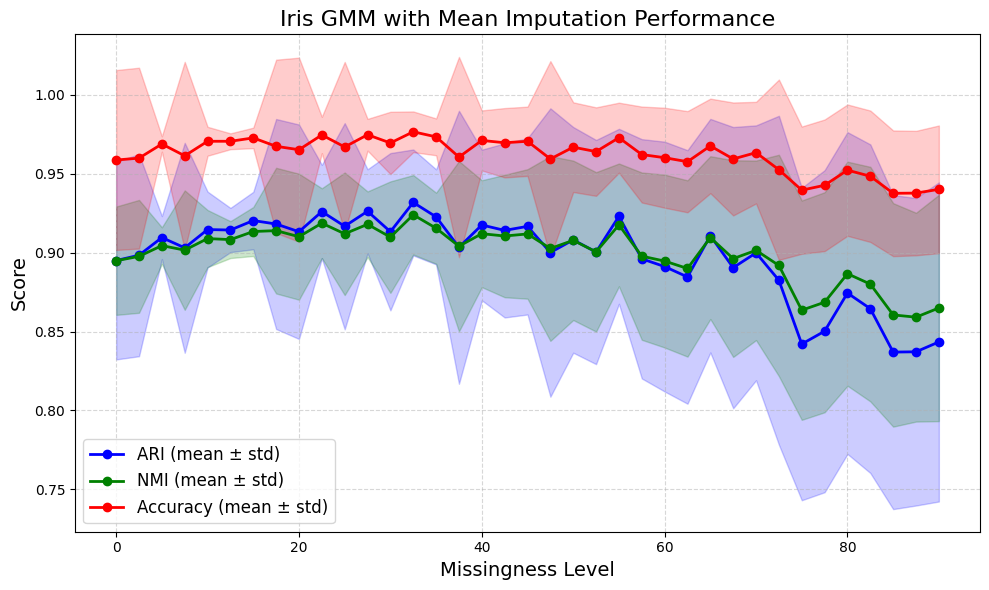

In [29]:
plot_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_mean_runs, nmi_mean_runs, acc_mean_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title="Iris GMM with Mean Imputation Performance"
)

## KNN imputation

In [30]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_gmm_pipeline)(missingness_percentages, X, y, n_classes, missingness, imputer=knn_imputer, missing_method="mar")
    for _ in range(n_runs)
)

ari_knn_runs = [r[0] for r in results]
nmi_knn_runs = [r[1] for r in results]
acc_knn_runs = [r[2] for r in results]

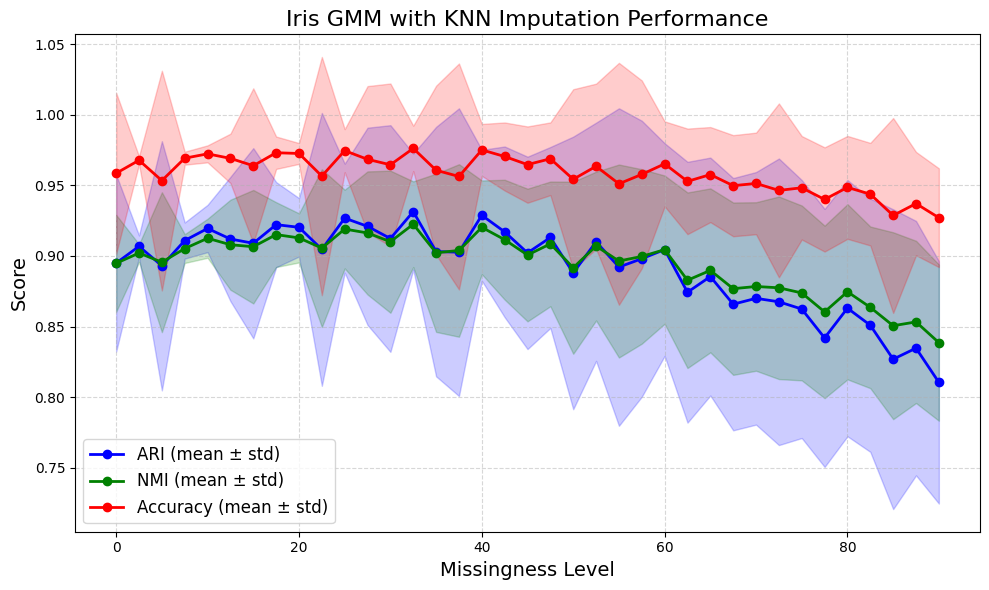

In [31]:
plot_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_knn_runs, nmi_knn_runs, acc_knn_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title="Iris GMM with KNN Imputation Performance"
)

## MICE imputation

In [32]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_gmm_pipeline)(missingness_percentages, X, y, n_classes, missingness, imputer=iterative_imputer, missing_method="mar")
    for _ in range(n_runs)
)

ari_mice_runs = [r[0] for r in results]
nmi_mice_runs = [r[1] for r in results]
acc_mice_runs = [r[2] for r in results]

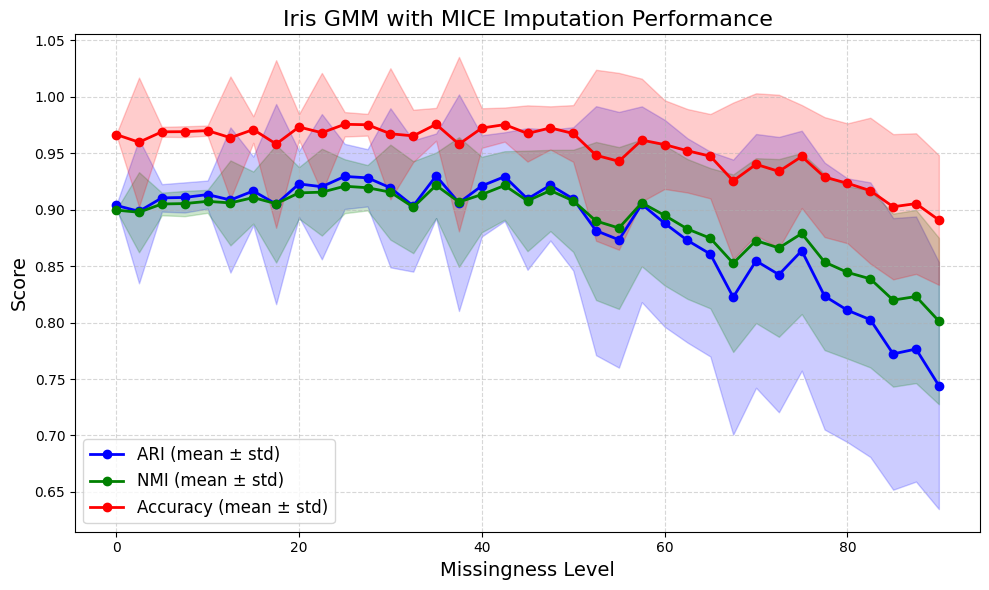

In [33]:
plot_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_mice_runs, nmi_mice_runs, acc_mice_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title="Iris GMM with MICE Imputation Performance"
)

## Missing-Aware GMM

In [34]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_gmm_pipeline)(missingness_percentages, X, y, n_classes, missingness, imputer=None, missing_method="mar")
    for _ in range(n_runs)
)

ari_gmm_runs = [r[0] for r in results]
nmi_gmm_runs = [r[1] for r in results]
acc_gmm_runs = [r[2] for r in results]

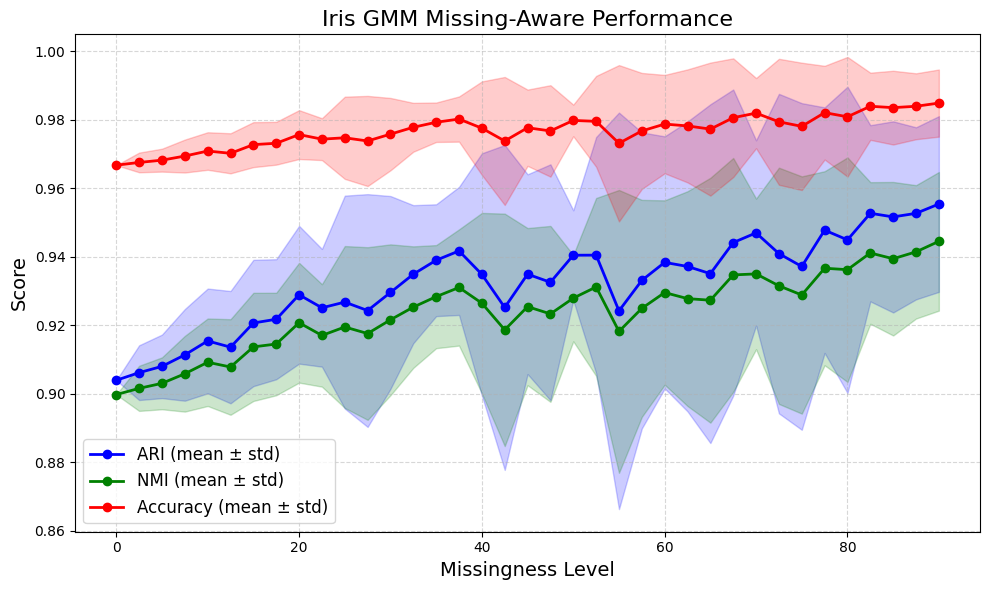

In [35]:
plot_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_gmm_runs, nmi_gmm_runs, acc_gmm_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title="Iris GMM Missing-Aware Performance"
)

## Plotting results

In [36]:
experiment_results = {
    "Mean": {
        "ARI": ari_mean_runs,
        "NMI": nmi_mean_runs,
        "ACC": acc_mean_runs,
    },
    "kNN": {
        "ARI": ari_knn_runs,
        "NMI": nmi_knn_runs,
        "ACC": acc_knn_runs,
    },
    "MICE": {
        "ARI": ari_mice_runs,
        "NMI": nmi_mice_runs,
        "ACC": acc_mice_runs,
    },
    "Missing-Aware GMM": {
        "ARI": ari_gmm_runs,
        "NMI": nmi_gmm_runs,
        "ACC": acc_gmm_runs,
    },
}

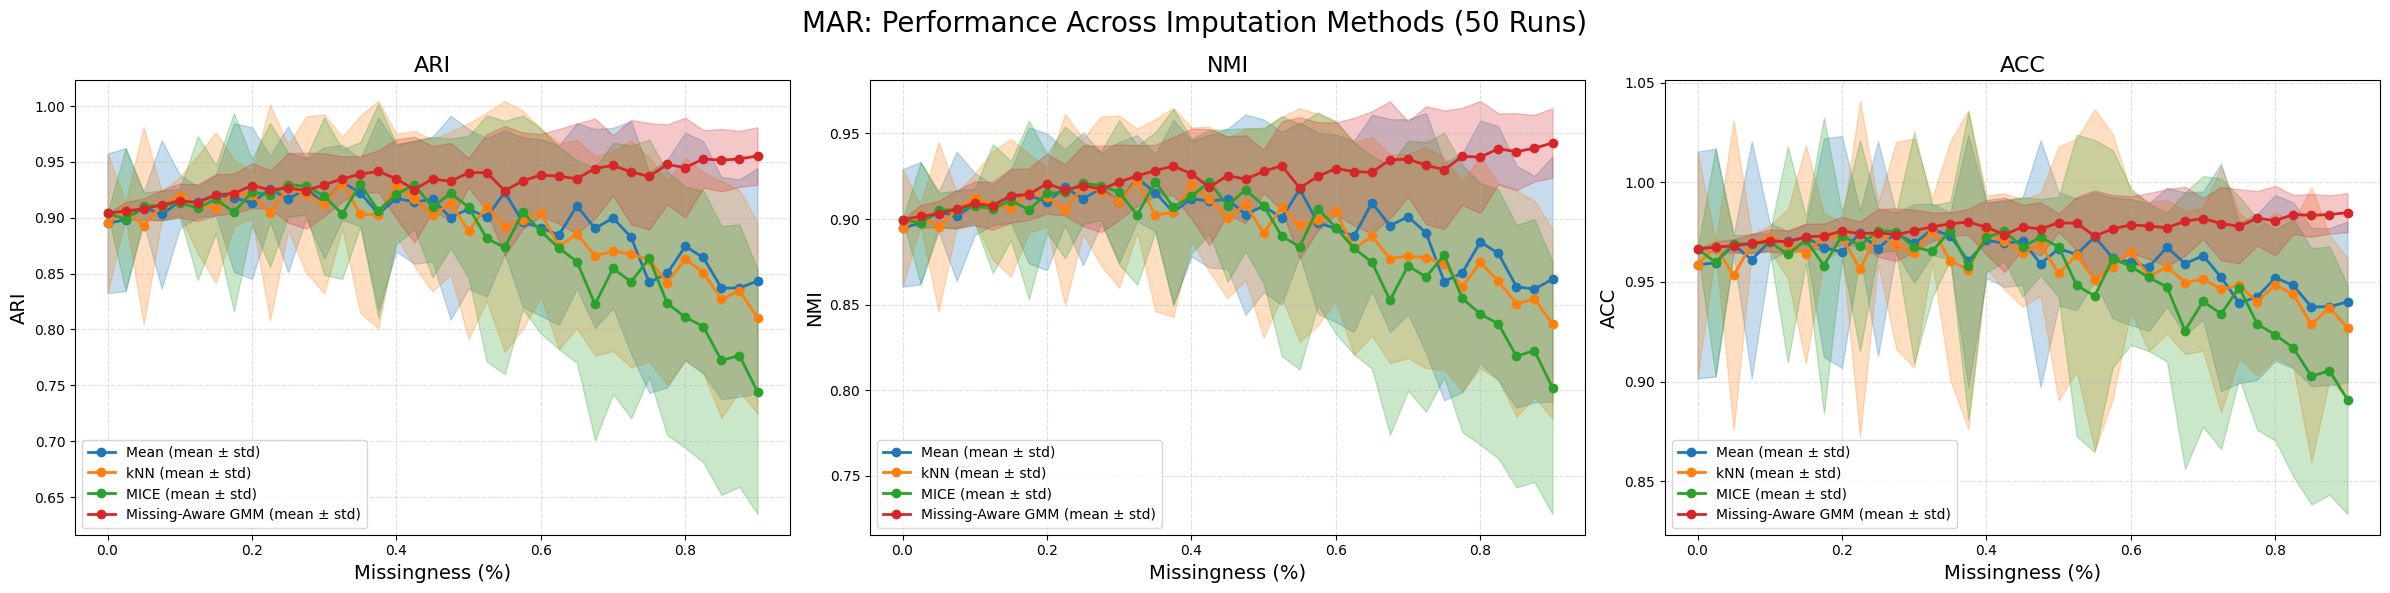

In [37]:
plot_experiment_results(
    missingness_percentages,
    experiment_results,
    title="MAR: Performance Across Imputation Methods (50 Runs)"
)

# Missing Completely at Random

## Loading Data

In [38]:
X, y, classes = load_iris(return_numpy=True, encode_labels=True)
n_classes = len(classes)

missing = missingness.apply_stratified(
    X, y,
    method="mcar",
    frac=0.25,
)

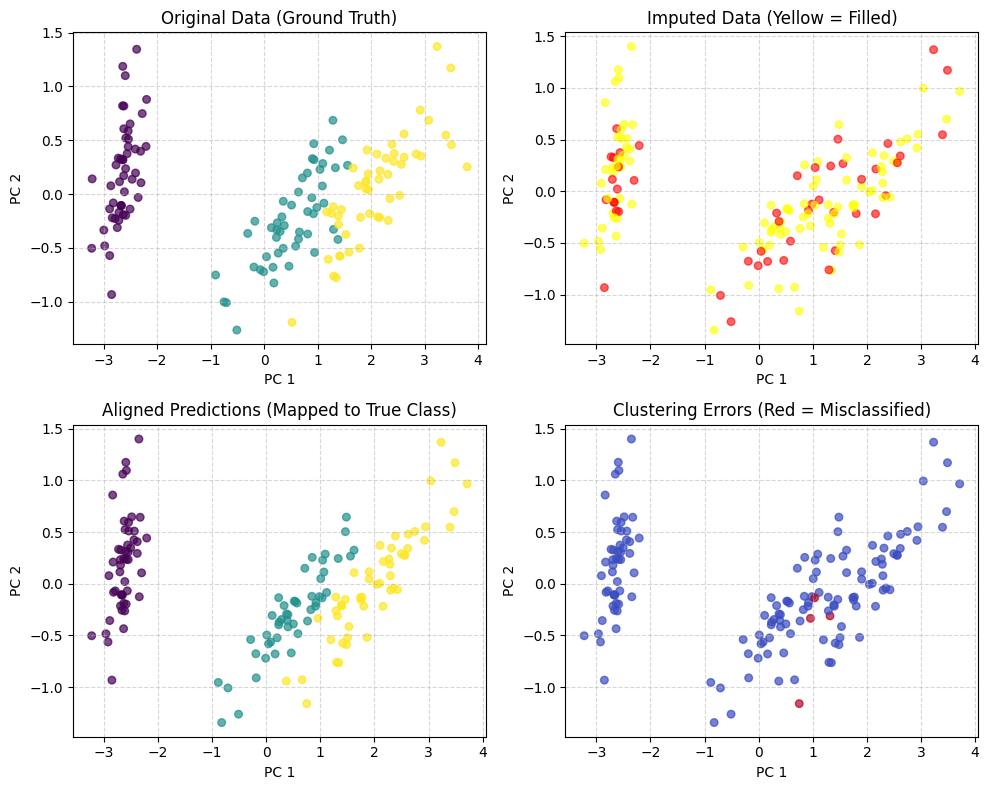

In [39]:
plot_imputation_and_alignment(X, y, n_classes, missing)

## Mean imputation

In [40]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_gmm_pipeline)(missingness_percentages, X, y, n_classes, missingness, imputer=mean_imputer, missing_method='mcar')
    for _ in range(n_runs)
)

ari_mean_runs = [r[0] for r in results]
nmi_mean_runs = [r[1] for r in results]
acc_mean_runs = [r[2] for r in results]

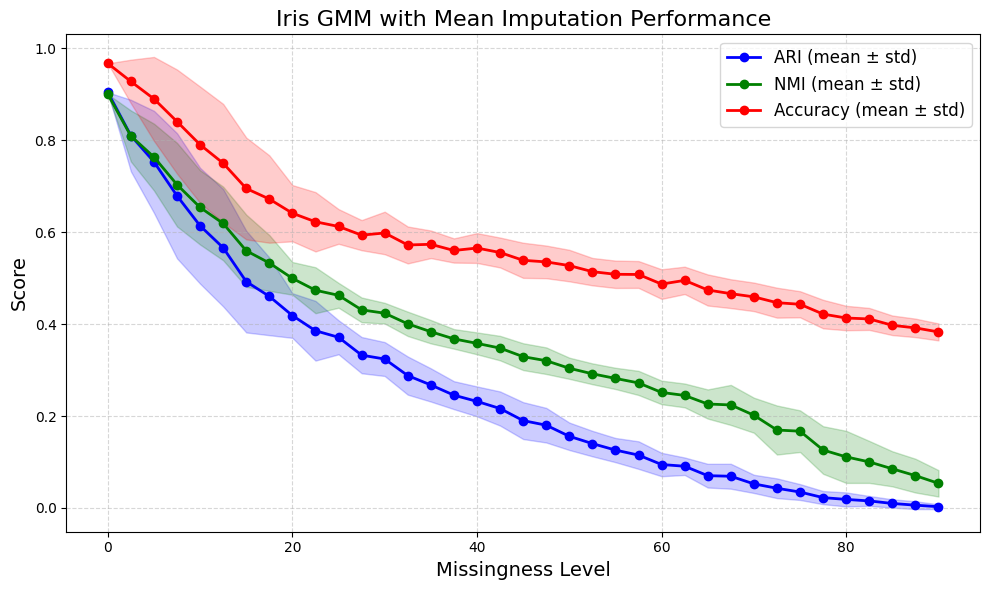

In [41]:
plot_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_mean_runs, nmi_mean_runs, acc_mean_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title="Iris GMM with Mean Imputation Performance"
)

## KNN Imputation

In [42]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_gmm_pipeline)(missingness_percentages, X, y, n_classes, missingness, imputer=knn_imputer, missing_method='mcar')
    for _ in range(n_runs)
)

ari_knn_runs = [r[0] for r in results]
nmi_knn_runs = [r[1] for r in results]
acc_knn_runs = [r[2] for r in results]

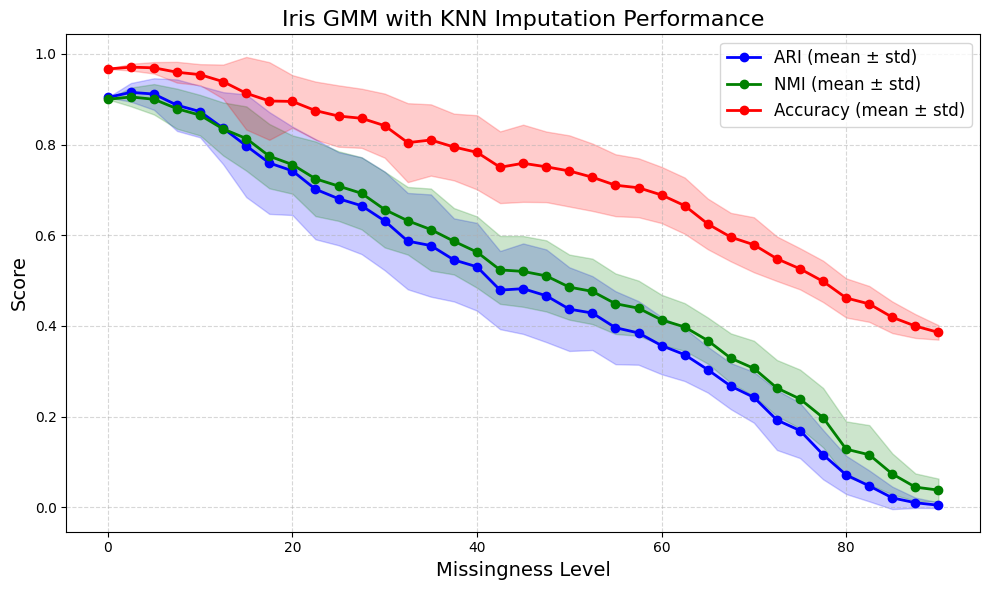

In [43]:
plot_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_knn_runs, nmi_knn_runs, acc_knn_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title="Iris GMM with KNN Imputation Performance"
)

## MICE imputation


In [44]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_gmm_pipeline)(missingness_percentages, X, y, n_classes, missingness, imputer=iterative_imputer, missing_method='mcar')
    for _ in range(n_runs)
)

ari_mice_runs = [r[0] for r in results]
nmi_mice_runs = [r[1] for r in results]
acc_mice_runs = [r[2] for r in results]

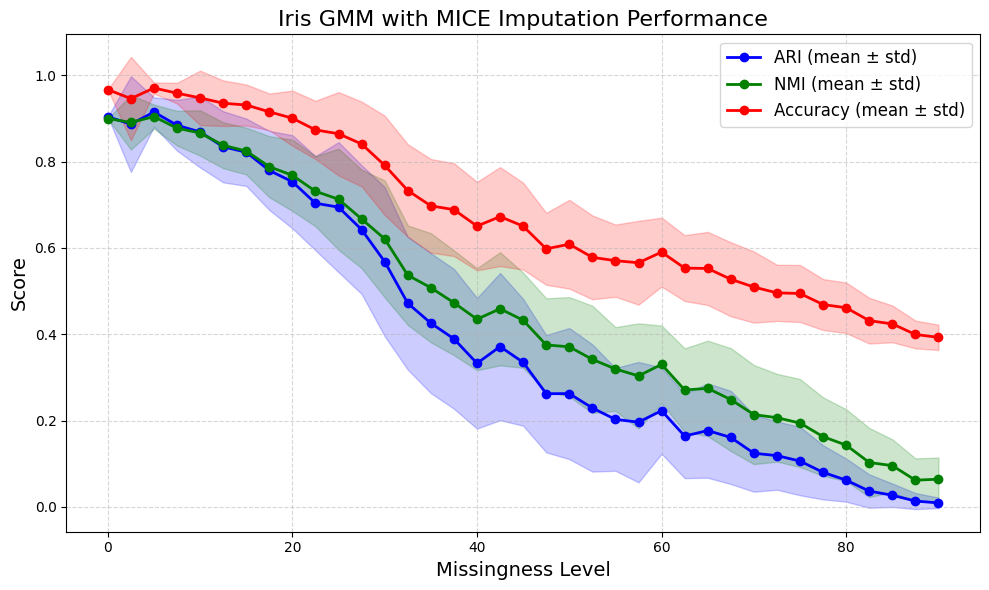

In [45]:
plot_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_mice_runs, nmi_mice_runs, acc_mice_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title="Iris GMM with MICE Imputation Performance"
)

## Missing-Aware GMM


In [49]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_gmm_pipeline)(missingness_percentages, X, y, n_classes, missingness, imputer=None, missing_method='mcar')
    for _ in range(n_runs)
)

ari_gmm_runs = [r[0] for r in results]
nmi_gmm_runs = [r[1] for r in results]
acc_gmm_runs = [r[2] for r in results]

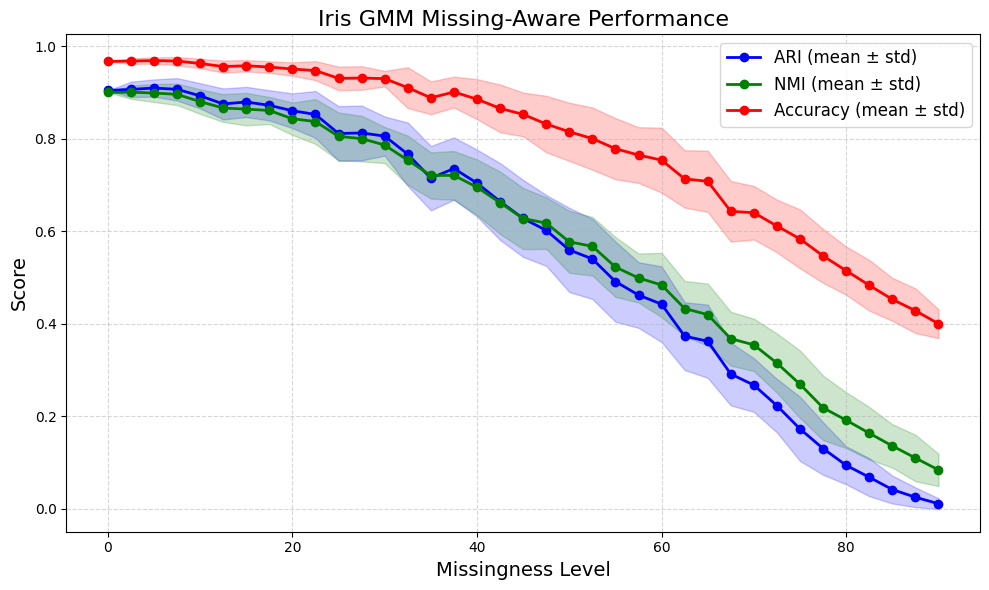

In [50]:
plot_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_gmm_runs, nmi_gmm_runs, acc_gmm_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title="Iris GMM Missing-Aware Performance"
)

## Plotting results

In [51]:
experiment_results = {
    "Mean": {
        "ARI": ari_mean_runs,
        "NMI": nmi_mean_runs,
        "ACC": acc_mean_runs,
    },
    "kNN": {
        "ARI": ari_knn_runs,
        "NMI": nmi_knn_runs,
        "ACC": acc_knn_runs,
    },
    "MICE": {
        "ARI": ari_mice_runs,
        "NMI": nmi_mice_runs,
        "ACC": acc_mice_runs,
    },
    "Missing-Aware GMM": {
        "ARI": ari_gmm_runs,
        "NMI": nmi_gmm_runs,
        "ACC": acc_gmm_runs,
    },
}

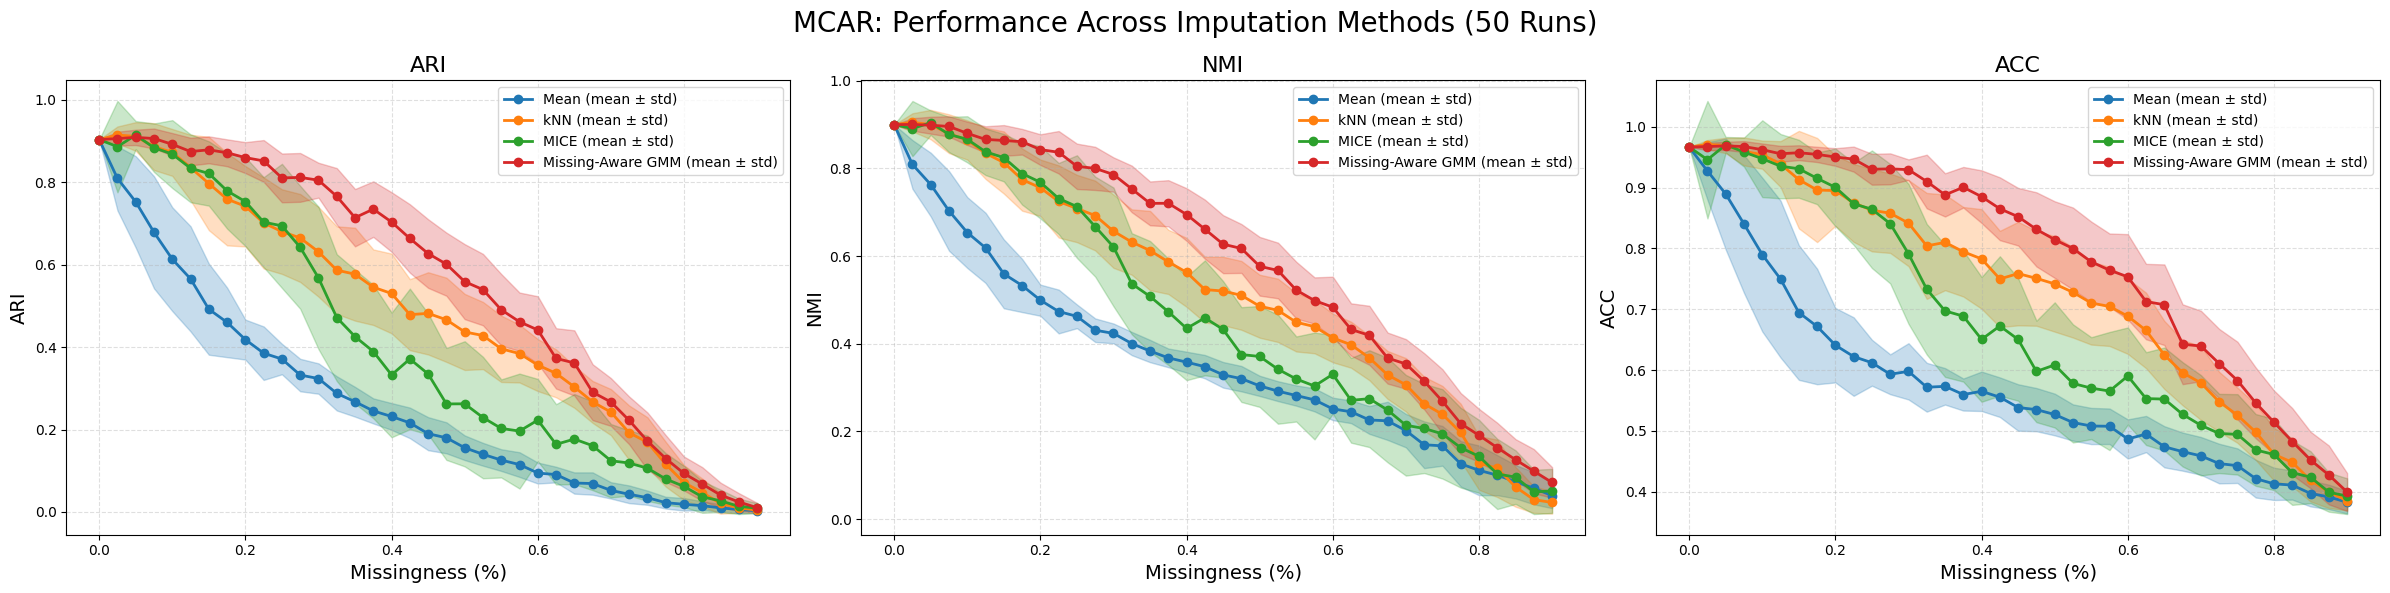

In [52]:
plot_experiment_results(
    missingness_percentages,
    experiment_results,
    title="MCAR: Performance Across Imputation Methods (50 Runs)"
)